# Example-15: Test data (ELETTRA)

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

False


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Test trajectories at locations can be generated for a given initial condition
# Set uncoupled model

model = Model(path='../config/elettra.yaml', model='uncoupled', dtype=dtype, device=device)

# Generate errors

model.make_error(5.0E-3, 1.0E-3)

# Compute transport matrices

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

True


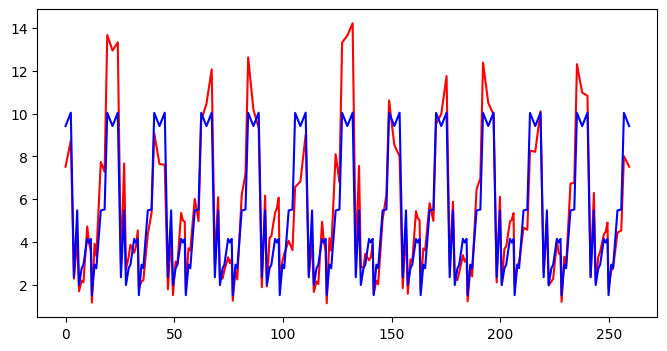

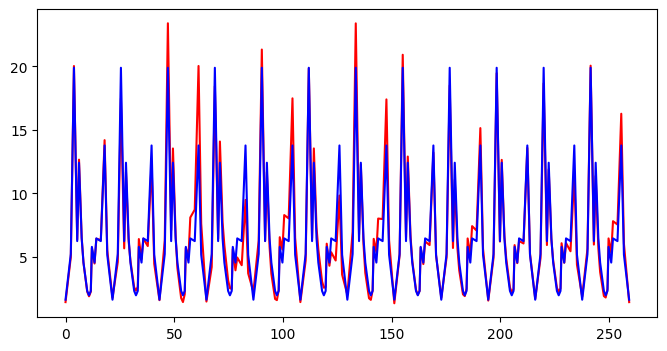

tensor(2.206166742690e+01, dtype=torch.float64)
tensor(1.525000934889e+01, dtype=torch.float64)


In [4]:
# Twiss parameters with errors

ax_out, bx_out, ay_out, by_out = model.out_cs.T

def rms(x):
    return (x**2).mean().sqrt()

bbx = 100.0*(model.bx - bx_out) / model.bx
bby = 100.0*(model.by - by_out) / model.by

plt.figure(figsize=(8, 4))
plt.errorbar(model.time, bx_out, color='red')
plt.errorbar(model.time, model.bx, color='blue')
plt.show()

plt.figure(figsize=(8, 4))
plt.errorbar(model.time, by_out, color='red')
plt.errorbar(model.time, model.by, color='blue')
plt.show()

print(rms(bbx))
print(rms(bby))

In [5]:
# Save model with errors

model.save('../elettra/error.json')

In [6]:
# Set initial condition

state = torch.tensor([0.00025, 0.0, 0.0001, 0.0], dtype=dtype, device=device)

torch.Size([194, 8192, 4])


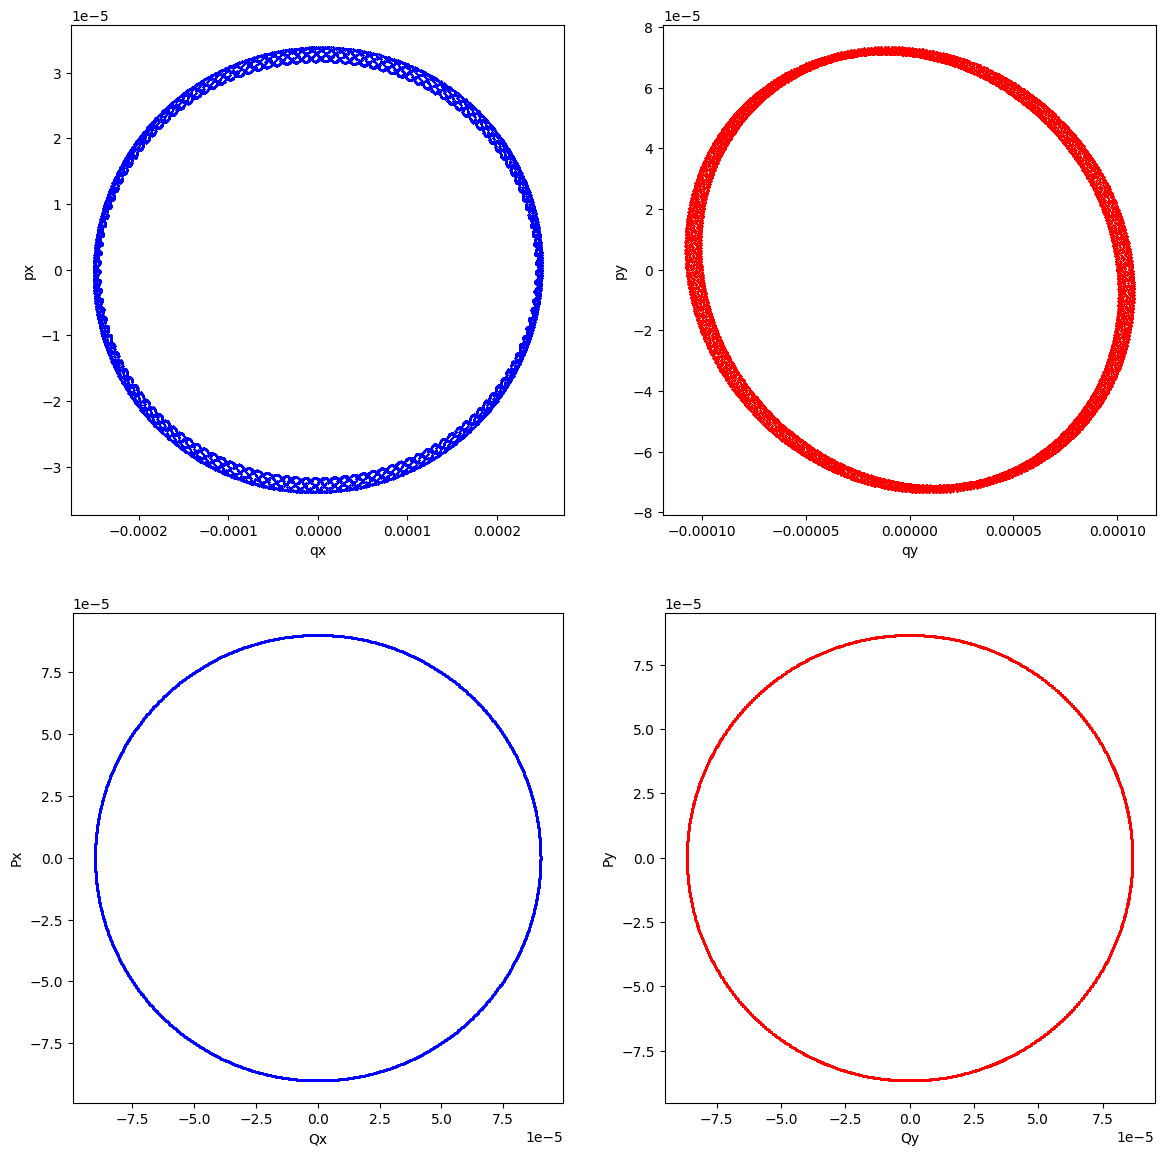

1.778403515809244e-19
2.200332524952205e-19


In [8]:
# Generate trajectories using transport matrices

length = 2*2**12
trajectory =  model.make_trajectory(state, length, error=True, transport=True)
print(trajectory.shape)

# Plot trajectory and floquet trajectory for given location index

index = 0

qx, px, qy, py = trajectory[index].T.cpu().numpy()
Qx, Px, Qy, Py = (model.out_normal[index].inverse() @ trajectory[index].T).cpu().numpy()

plt.figure(figsize=(2*7, 2*7))

# qx-px

ax1 = plt.subplot(221)
ax1.scatter(qx, px, marker='x', s=1, color='blue')
ax1.set_xlabel('qx')
ax1.set_ylabel('px')
ax1.set_aspect('auto')

# qy-py

ax2 = plt.subplot(222)
ax2.scatter(qy, py, marker='x', s=1, color='red')
ax2.set_xlabel('qy')
ax2.set_ylabel('py')
ax2.set_aspect('auto')

# Qx-Px

ax3 = plt.subplot(223)
ax3.scatter(Qx, Px, marker='x', s=1, color='blue')
ax3.set_xlabel('Qx')
ax3.set_ylabel('Px')
ax3.set_aspect('equal')

# Qy-Py

ax4 = plt.subplot(224)
ax4.scatter(Qy, Py, marker='x', s=1, color='red')
ax4.set_xlabel('Qy')
ax4.set_ylabel('Py')
ax4.set_aspect('equal')

plt.show()

# Conservation of invariants

print((Qx**2 + Px**2).std().item())
print((Qy**2 + Py**2).std().item())

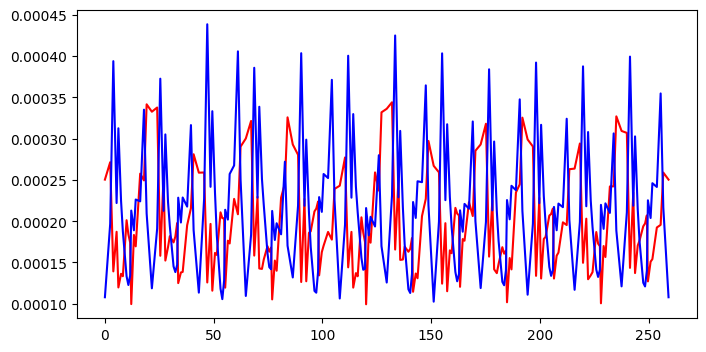

In [9]:
# Max x and y positions over turns at locations

qxs, pxs, qys, pys = trajectory.swapaxes(0, -1)

plt.figure(figsize=(8, 4))
plt.errorbar(model.time, qxs.T.max(-1).values, color='red')
plt.errorbar(model.time, qys.T.max(-1).values, color='blue')
plt.show()

In [10]:
# Save TbT

df = pandas.DataFrame()

X = {name: data.numpy() for name, data in zip(model.name, qxs.T)}
Y = {name: data.numpy() for name, data in zip(model.name, qys.T)}
I = {name: data.numpy() for name, data in zip(model.name, torch.ones_like(qxs.T))}

df['X'] = X
df['Y'] = Y
df['I'] = I

df.to_pickle("../elettra/tbt.pkl.gz", compression="gzip")